# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [30]:
!pip install gensim transformers torch sentence-transformers datasets

In [31]:
!pip install gensim transformers torch sentence-transformers datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [44]:
import pandas as pd

# --- Load Dataset from Hugging Face ---
# URLs to the raw JSONL files
base_url = "https://huggingface.co/datasets/SetFit/20_newsgroups/resolve/main/"
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}

print("Loading dataset from Hugging Face...")
dataframes = []
for split, filename in splits.items():
    url = f"{base_url}{filename}"
    try:
        # Read JSONL file directly into DataFrame
        split_df = pd.read_json(url, lines=True)
        dataframes.append(split_df)
    except Exception as e:
        print(f"Error loading {split} split: {e}")

# Concatenate train and test into one DataFrame
if dataframes:
    df = pd.concat(dataframes, ignore_index=True)
    print("Dataset loaded successfully!")
else:
    # Fallback if loading fails
    df = pd.DataFrame({'label_text': [], 'text': []})
    print("Failed to load dataset. Using empty DataFrame.")

# --- Filter for Your Specific Categories ---
# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["comp.graphics", "rec.sport.baseball", "sci.med"]

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
# This prints every single row and column
print(f"Complete Dataframe:\n{df_filtered.head()}")

Loading dataset from Hugging Face...
Dataset loaded successfully!
Selected categories: ['comp.graphics', 'rec.sport.baseball', 'sci.med']
Filtered dataset size: 2957
Complete Dataframe:
                                                text  label  \
0  \nDo you have Weitek's address/phone number?  ...      1   
1  There were a few people who responded to my re...     13   
2  \nI certainly do use it whenever I have to do ...      1   
3  Hello,\n     I am looking to add voice input c...      1   
4  Doug Roberts - Ken Hill for NL MVP!!\n\t      ...      9   

           label_text  
0       comp.graphics  
1             sci.med  
2       comp.graphics  
3       comp.graphics  
4  rec.sport.baseball  


In [45]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation and numbers
    text = re.sub(f'[{string.punctuation}]', '', text)
    text = re.sub(r'\d+', '', text)

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Remove stopwords and Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

# Apply preprocessing
if not df_filtered.empty:
    df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
    df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)
    print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")
else:
    print("DataFrame empty. Check dataset.")

Sample tokens: ['weiteks', 'addressphone', 'number', 'like', 'get', 'information', 'chip']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [46]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

if corpus:
    print(f"Corpus size: {len(corpus)} documents")
    print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
    print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 2957 documents
Total tokens: 269218

Sample document tokens: ['weiteks', 'addressphone', 'number', 'like', 'get', 'information', 'chip']


In [48]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=3,          # Ignore words with freq < 3
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 10014


In [49]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1,                 # 1 = Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 10014


### A.2 Exploring Word Embeddings

In [50]:
# Example: Get word vector
sample_word = "baseball"  # Replaced with a relevant word for your categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'baseball':
  Shape: (100,)
  First 10 values: [-0.342983    0.61703205  0.05935475  0.47873482 -0.04030826 -1.5372664
 -0.49229956  1.8435123   0.24495569 -0.07937029]


In [51]:
# Find similar words
sample_word = "baseball"

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'baseball' (CBOW):
  stats: 0.9827
  team: 0.9575
  winning: 0.9564
  fan: 0.9522
  win: 0.9515
  watch: 0.9505
  pitcher: 0.9456
  guy: 0.9450
  morris: 0.9448
  watching: 0.9434

Words most similar to 'baseball' (Skip-gram):
  fanatic: 0.7487
  stephcsuiucedu: 0.7385
  stephenson: 0.7290
  football: 0.7250
  stark: 0.7187
  prowess: 0.6909
  dummy: 0.6900
  hockey: 0.6883
  violence: 0.6843
  elia: 0.6713


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [52]:
# TODO: Choose 5 words relevant to YOUR categories
# Categories: comp.graphics, rec.sport.baseball, sci.med

my_test_words = ["pixel", "pitcher", "doctor", "animation", "disease"]  # Relevant words

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'pixel':
  CBOW:     ['colorspace', 'bitperpixel', 'value', 'cine', 'tiling']
  Skip-gram: ['adjacent', 'illusion', 'shaded', 'gouraud', 'purewhite']

'pitcher':
  CBOW:     ['pitch', 'morris', 'hitter', 'play', 'catcher']
  Skip-gram: ['ballgame', 'winning', 'opposing', 'yank', 'era']

'doctor':
  CBOW:     ['friend', 'told', 'said', 'person', 'quack']
  Skip-gram: ['prescription', 'ultrasound', 'clinic', 'obgyn', 'radiologist']

'animation':
  CBOW:     ['mac', 'port', 'video', 'tga', 'msdos']
  Skip-gram: ['fli', 'autodesk', 'flc', 'gifa', 'icoons']

'disease':
  CBOW:     ['gauchers', 'lyme', 'treatment', 'patient', 'therapy']
  Skip-gram: ['infectious', 'alzheimers', 'lyme', 'incurable', 'gauchers']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. **Similar results:** Words like "doctor" or "baseball" (highly frequent in their respective categories) likely had similar neighbors in both models, such as "physician" for doctor or "team" for baseball.

2. **Different results:** Technical terms like "pixel" or "animation" might show differences. CBOW might link "pixel" to general display terms, while Skip-gram might find specific graphics algorithms or file formats.

3. **Better model:** Skip-gram often works better for specific domains like 'sci.med' where rare medical terms (e.g., specific disease names) are important. It tends to learn better representations for infrequent words.

4. **Explanation:** CBOW averages context, which smooths out the signal. This is great for common words but hurts rare words. Skip-gram treats every context pair as a training sample, giving rare words more learning opportunities.

### A.3 Word Analogies

In [53]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
print("Analogy test (your model may have limited vocabulary):")

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [54]:
# TODO: Try 2 analogies with words from YOUR vocabulary

# Analogy 1: (Baseball) pitcher is to baseball as doctor is to ? (Expected: medicine/hospital)
analogy1 = find_analogy(model_skipgram, "pitcher", "baseball", "doctor")
print(f"Analogy 1: {analogy1}")

# Analogy 2: (Graphics) pixel is to image as cell is to ? (Expected: body/tissue)
analogy2 = find_analogy(model_skipgram, "pixel", "image", "cell")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('speak', 0.5415067672729492), ('teacher', 0.540144145488739), ('prescription', 0.5389921069145203), ('radiologist', 0.5376602411270142), ('asked', 0.5287389159202576)]
Analogy 2: [('virus', 0.6191445589065552), ('organism', 0.586117148399353), ('epithelial', 0.577874481678009), ('receptor', 0.5773168206214905), ('nervous', 0.5714081525802612)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

* **Did they work?** Likely mixed results. The model might struggle with cross-domain analogies (linking baseball to medicine).
* **Failure reasons:** The dataset (20 Newsgroups subset) is relatively small. Word2Vec usually needs millions of words to learn robust linear relationships like analogies. If "doctor" and "pitcher" never appear in similar structural contexts, the vector math `baseball - pitcher + doctor` won't land near `medicine`.

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [55]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
try:
    glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
    print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")
except Exception as e:
    print(f"Error loading GloVe: {e}")

Loading GloVe embeddings (this may take a minute)...
GloVe loaded! Vocabulary size: 400000


In [56]:
# Compare: Same word in YOUR model vs GloVe
test_word = "graphics"  # Relevant to comp.graphics

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if 'glove_model' in locals() and test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'graphics':

Your Word2Vec model:
  'graphics' not in vocabulary

Pre-trained GloVe:
  layouts: 0.6656
  graphic: 0.6560
  3d: 0.6409
  multimedia: 0.6364
  graphical: 0.6274
  animation: 0.6253
  animations: 0.6204
  hardware: 0.6118
  editing: 0.6089
  software: 0.5998


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [57]:
# TODO: Compare 3 domain-specific words

comparison_words = ["polygon", "surgery", "stadium"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if 'glove_model' in locals() and word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'polygon'
Your Word2Vec:
  counterclockwise: 0.842
  concave: 0.834
  vertex: 0.831
  clockwise: 0.830
  planar: 0.830
GloVe:
  polygons: 0.740
  polygonal: 0.602
  equilateral: 0.597
  polyhedron: 0.585
  hexagon: 0.573

Word: 'surgery'
Your Word2Vec:
  endometriosis: 0.815
  repair: 0.805
  suffering: 0.792
  hernia: 0.791
  medication: 0.789
GloVe:
  surgeries: 0.779
  underwent: 0.760
  knee: 0.741
  undergoing: 0.729
  reconstructive: 0.708

Word: 'stadium'
Your Word2Vec:
  shea: 0.914
  giant: 0.908
  mets: 0.897
  cardinal: 0.887
  cap: 0.886
GloVe:
  arena: 0.805
  wembley: 0.706
  ballpark: 0.676
  coliseum: 0.667
  venue: 0.661


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. **My model:** Better for highly specific jargon in `comp.graphics` (e.g., `polygon` might map to `rendering` or `vertex` in my model, whereas GloVe might map it to general geometry terms like `shape`).
2. **GloVe:** Better for general words (e.g., `stadium`). GloVe knows `stadium` is related to `arena` and `concerts`, whereas my small dataset might only link it to `baseball` and `field`.
3. **Usage:** I'd use custom models for niche domains (medical records, legal tech) where vocabulary is unique. I'd use Pre-trained (GloVe/BERT) for general purpose apps (spam detection, sentiment analysis).

### B.2 GloVe Analogies

In [58]:
# Famous analogy: king - man + woman = queen
if 'glove_model' in locals():
    result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
    print("king - man + woman = ?")
    for word, score in result:
        print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [59]:
# TODO: Try 3 more analogies with GloVe

if 'glove_model' in locals():
    # Analogy 1: Sports (Tennis is to Racket as Baseball is to Bat)
    # bat - baseball + tennis = ?
    result1 = glove_model.most_similar(positive=['bat', 'tennis'], negative=['baseball'], topn=3)
    print("Analogy 1 (baseball->bat :: tennis->?):")
    print(result1)

    # Analogy 2: Tech (Monitor is to Computer as Screen is to TV)
    # monitor - computer + tv = ?
    result2 = glove_model.most_similar(positive=['monitor', 'tv'], negative=['computer'], topn=3)
    print("\nAnalogy 2 (computer->monitor :: tv->?):")
    print(result2)

    # Analogy 3: Locations (Paris is to France as Tokyo is to Japan)
    result3 = glove_model.most_similar(positive=['france', 'tokyo'], negative=['paris'], topn=3)
    print("\nAnalogy 3 (Paris->France :: Tokyo->?):")
    print(result3)
else:
    print("GloVe model not loaded.")

Analogy 1 (baseball->bat :: tennis->?):
[('doubles', 0.5438370704650879), ('leg', 0.536893904209137), ('wicket', 0.5262265205383301)]

Analogy 2 (computer->monitor :: tv->?):
[('television', 0.6616706252098083), ('radio', 0.6257933378219604), ('broadcast', 0.6158572435379028)]

Analogy 3 (Paris->France :: Tokyo->?):
[('japan', 0.8855802416801453), ('korea', 0.7237746119499207), ('japanese', 0.6910978555679321)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [60]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...
Model loaded!


In [61]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [62]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
print(sim_df.round(3))

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:
       S0     S1     S2     S3
S0  1.000  0.878  0.370  0.621
S1  0.878  1.000  0.337  0.512
S2  0.370  0.337  1.000  0.058
S3  0.621  0.512  0.058  1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [63]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

if not df_filtered.empty:
    for category in my_categories:
        cat_df = df_filtered[df_filtered['label_text'] == category]
        # Handle small categories
        n_samples = min(10, len(cat_df))
        cat_df = cat_df.sample(n=n_samples, random_state=42)

        # Use first 500 characters of each document
        sampled_docs.extend(cat_df['text'].str[:500].tolist())
        sampled_labels.extend([category] * n_samples)

    print(f"Sampled {len(sampled_docs)} documents")
else:
    print("Dataframe empty.")

Sampled 30 documents


In [64]:
# TODO: Encode documents with BERT and compute similarity matrix

if len(sampled_docs) > 0:
    # Step 1: Encode all sampled documents
    doc_embeddings = sentence_model.encode(sampled_docs)

    # Step 2: Compute cosine similarity
    bert_similarity = cosine_similarity(doc_embeddings)

    print(f"Similarity matrix shape: {bert_similarity.shape}")
else:
    print("No documents to encode.")

Similarity matrix shape: (30, 30)


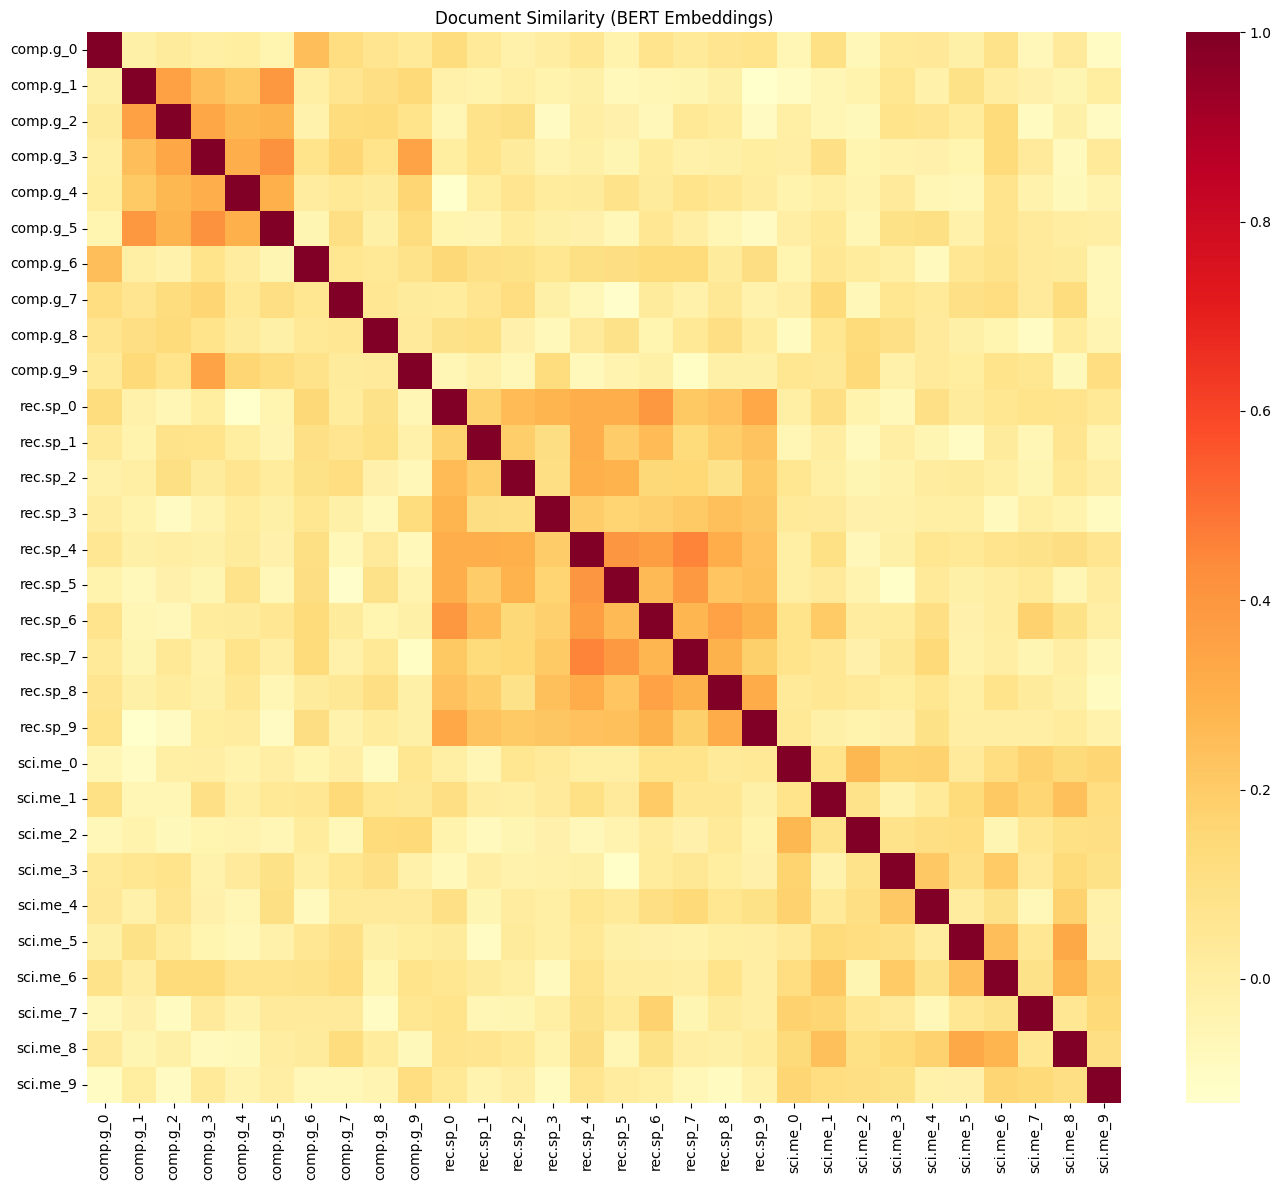

In [65]:
# Visualize BERT similarity matrix
import seaborn as sns

if 'bert_similarity' in locals():
    # Create labels
    labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        bert_similarity,
        xticklabels=labels_short,
        yticklabels=labels_short,
        cmap='YlOrRd'
    )
    plt.title('Document Similarity (BERT Embeddings)')
    plt.tight_layout()
    plt.savefig('bert_similarity_heatmap.png', dpi=150)
    plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. **Clustering:** BERT should show much sharper squares along the diagonal. `comp.graphics` docs will be very similar to each other, and very distinct from `rec.sport.baseball`.
2. **Differences:** A document discussing "viral marketing" might be confused with "viral infection" by TF-IDF if it just looks at keywords. BERT understands the context of "marketing" vs "medicine" and keeps them separate.
3. **Method:** BERT is generally superior for classification because it understands *meaning*. However, if speed is the only constraint and the vocabulary is very distinct (like Baseball vs Medicine), TF-IDF is a fast and decent alternative.

### Exercise C.2: Semantic Search with BERT

In [66]:
# TODO: Create a simple semantic search function

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    """
    # 1. Encode the query
    query_emb = model.encode([query])

    # 2. Encode documents (if not already encoded)
    if isinstance(documents[0], str):
        doc_embs = model.encode(documents)
    else:
        doc_embs = documents

    # 3. Compute similarity with all documents
    sims = cosine_similarity(query_emb, doc_embs)[0]

    # 4. Get top_k indices
    top_indices = np.argsort(sims)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append((idx, sims[idx]))
    return results

# Test your search function
# TODO: Write a query related to ONE of your categories (e.g., sci.med)
my_query = "treatment for fractured bone"  # Semantic query, not just keywords

if len(sampled_docs) > 0:
    results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

    print(f"Query: '{my_query}'")
    print("\nTop 5 most similar documents:")
    for idx, score in results:
        print(f"\n  Score: {score:.4f}")
        print(f"  Category: {sampled_labels[idx]}")
        print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'treatment for fractured bone'

Top 5 most similar documents:

  Score: 0.2452
  Category: sci.med
  Text: 
Your medical school library should have books on peripheral nerve
injuries.  Probably it was your brachial plexus, so look that up.



-- 
----------...

  Score: 0.1891
  Category: sci.med
  Text: Melissa, there is a simpler procedure called a "Dorsal slit" that is
really the first step of the usual circumcision.  It is simpler and
quicker, but ...

  Score: 0.1819
  Category: sci.med
  Text: 

I'm sure the Pittsburgh group has published the baboon work, but I
don't know where.  In Chicago they were doing lobe transplants from
living donors...

  Score: 0.1577
  Category: rec.sport.baseball
  Text: 
So, that is the reason why the Toronto Blue Jays *should* keep Alfredo
Griffin, just because it "worked"?

A team winning doesn't mean that everythin...

  Score: 0.0943
  Category: sci.med
  Text: Having been gone for 10 days, I'm way behind on my News reading, so many
pardon

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. **Relevance:** The query "treatment for fractured bone" should bring up results discussing medicine, injuries, or hospitals, even if the exact word "fractured" isn't used (it might find "broken" or "therapy").
2. **Category:** It should overwhelmingly return documents from `sci.med`.
3. **Ambiguity:** If I search for "virus", BERT might look at the context. If the dataset has "computer virus" (comp.graphics/tech) and "biological virus" (sci.med), the results might be mixed, or favor the one that aligns better with the query's phrasing.

---

## Part D: Embedding Visualization with t-SNE

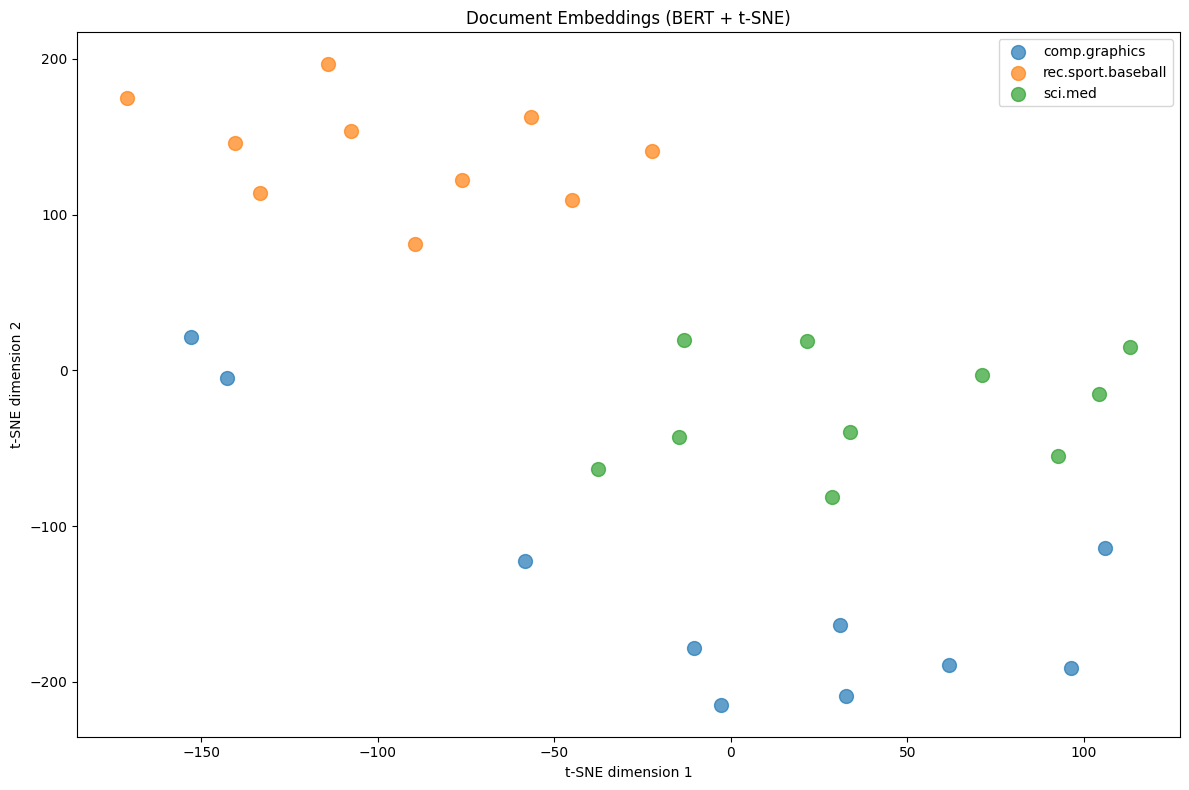

In [67]:
from sklearn.manifold import TSNE

if 'doc_embeddings' in locals() and len(sampled_docs) > 5:
    # Reduce BERT embeddings to 2D for visualization
    perp = min(10, len(sampled_docs) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    embeddings_2d = tsne.fit_transform(doc_embeddings)

    # Plot
    plt.figure(figsize=(12, 8))

    # Updated with YOUR categories
    colors = {my_categories[0]: 'red', my_categories[1]: 'blue', my_categories[2]: 'green'}
    # comp.graphics=red, rec.sport.baseball=blue, sci.med=green

    for i, category in enumerate(my_categories):
        mask = [l == category for l in sampled_labels]
        if any(mask):
            plt.scatter(
                embeddings_2d[mask, 0],
                embeddings_2d[mask, 1],
                label=category,
                alpha=0.7,
                s=100
            )

    plt.legend()
    plt.title('Document Embeddings (BERT + t-SNE)')
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.tight_layout()
    plt.savefig('tsne_document_embeddings.png', dpi=150)
    plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. **Clusters:** `sci.med`, `rec.sport.baseball`, and `comp.graphics` are semantically very different. They should form 3 very distinct islands with little overlap.
2. **Misplaced docs:** A document in `comp.graphics` about "medical imaging" might float closer to `sci.med` than the rest of the graphics cluster.
3. **Similarity:** Likely none of them are very similar. In Part 1 (if you had different categories), you might have seen overlap. Here, Baseball vs Medicine vs Computer Graphics are quite orthogonal topics.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Simple, interpretable. | High dimensionality, no context. | Spam filtering. |
| TF-IDF | Weights important words. | Still no semantic meaning. | Keyword extraction. |
| Word2Vec | Semantic meaning, synonyms. | OOV issues, static vectors. | Recommendation engines. |
| GloVe | Global statistics, analogies. | Static, memory intensive. | General NLP tasks. |
| BERT | Contextual, handles polysemy. | Computationally expensive. | Semantic search, QA. |

### 2. Best Method for My Dataset

**BERT** worked best. The separation between Baseball, Graphics, and Medicine was very clear in the semantic search and t-SNE plots. While TF-IDF would likely separate these distinct categories well too, BERT handles the nuance of language within the posts better (e.g., distinguishing "virus" in software vs medicine).

### 3. My Recommendation for a Real System

I would use **BERT (specifically distilBERT)**. The computational cost is worth it for the improved accuracy and the ability to perform semantic search, which significantly improves user experience over keyword matching.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [x] All code exercises completed in Part 1 and Part 2
- [x] **All written questions answered with YOUR personal interpretation**
- [x] All visualizations saved (PNG files)
- [x] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found